<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExOWI5emc0dnp2Z24ycDJibGkxbmM1ZjU2aDdqaW5yODdic3JzZjMxcyZlcD12MV9naWZzX3NlYXJjaCZjdD1n/1gXg8Hrjah7bmm45W7/giphy.webp" alt="Eigen" width="500" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Examples of Solution Eigen values & Eigen Vectors</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Seismic Desing</p>
  <p><b>Year:</b> MARCH - 2026</p>

</div>

### Libraries

In [1]:
import sys
import os
import glob
from pathlib import Path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
from numpy.linalg import eig, inv  
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from repo_seismic_desing import *

## Example
![alt text](image-10.png)

#### Data

In [3]:
ProjecName = 'Edifico Rivadavia'

h = 3.60                                                                                                                        # Height of a single floor [m]
sto = 30                                                                                                                         # Number of floors
H = np.ones(sto) * h                                                                                                            # Vector containing the heights of all floors [m]
span = [5,5]                                                                                                                    # Number of spans in x and y directions
LVx = 30/5                                                                                                                          # longitud de vanos (se emplea unicamente para graficar)
LVy = 40/5
LV = LVx
Afloor = (span[0] * LVx) * (span[1] * LVy)
WD = 0.25
WL = 0.20
Wpp = 1.18
wpi = Afloor * (1.0* WD + 1.0 * WL + 1.0 * Wpp) 
E = 2000000                                                                                                                     # Elastic modulus in [T/m^2]
u = 0.2                                                                                                                         # Poisson's ratio of the material (dimensionless).
G = E / (2*(1 + u))                                                                                                             # Shear modulus calculated using the relationship between E and u [T/m^2].
f = 1/5                                                                                                                         # shape factor
C = 1.10                                                                                                                        # Size of the column in [m] (Square Columns)
iner = C**4 / 12                                                                                                                # Moment of inertia of columns [m^4]
A = C * C                                                                                                                       # Area [m^2]
facIene = 0.80
INERs = np.ones(sto) * iner * facIene                                                                                           # Vector containing the inertia of columns per floor [m^4]
iner = iner * facIene
g = 9.8                                                                                                                         # Gravitational acceleration [m/s^2]
MPall = np.ones(sto) * (wpi / g)                                                                                                # Vector containing the mass of each floor [T·s^2/m]
maxdrift = 1.50                                                                                                                 # Define maximum allowed drift percentage
fss = 1.5                                                                                                                        # factor de escala para dibujo de columnas y vigas
C = C * fss                                                                                                                      # tamaño de columnas y vigas para dibujo


#----------City---------
city = 'Guayas - Guayaquil - Guayaquil'
#---------Soild type--------
suelo = 'D'
#--------- PGA TR475 --------
z = 0.35
#--------- Amplification Soild Factors -------
zone = 'III'
fads = [1.25,1.28,1.19]
rr = 1.2
R = 8
I = 1.25

#------- Colocation r -------
r = np.ones(len(H))


# Display results for verification
print('\x1b[1;34m')
print("="*120)
print('\x1b[1;34m  Floor Weigth:', wpi)
print('\x1b[1;34m  Vector of floor heights (H):', H)
print('\x1b[1;34m  Vector of column inertias (INERs):', INERs)
print('\x1b[1;34m  Vector of floor masses (MPall):', MPall)
print('\x1b[1;34m  Vector of r:', r)
print("="*120)


  Floor Weigth: 1955.9999999999998
  Vector of floor heights (H): [3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6
 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6 3.6]
  Vector of column inertias (INERs): [0.09760667 0.09760667 0.09760667 0.09760667 0.09760667 0.09760667
 0.09760667 0.09760667 0.09760667 0.09760667 0.09760667 0.09760667
 0.09760667 0.09760667 0.09760667 0.09760667 0.09760667 0.09760667
 0.09760667 0.09760667 0.09760667 0.09760667 0.09760667 0.09760667
 0.09760667 0.09760667 0.09760667 0.09760667 0.09760667 0.09760667]
  Vector of floor masses (MPall): [199.59183673 199.59183673 199.59183673 199.59183673 199.59183673
 199.59183673 199.59183673 199.59183673 199.59183673 199.59183673
 199.59183673 199.59183673 199.59183673 199.59183673 199.59183673
 199.59183673 199.59183673 199.59183673 199.59183673 199.59183673
 199.59183673 199.59183673 199.59183673 199.59183673 199.59183673
 199.59183673 199.59183673 199.59183673 199.59183673 199.59183673]
  Vect

#### Stiffness Matrix for each Floor

In [4]:
Kfloor = Assamble_K_M(span=span,iner= iner,H=H,E=E,G=G,f=f,A=A, Mall= MPall)
k = Kfloor.kfloor()
k_frame = pd.DataFrame(k, columns=['Stiffness Vector'])                                                                        # Create a DataFrame from the stiffness vector
k_frame.head(len(k))

number of columns per floor =  36


,Stiffness Vector
0,1.744970e+06
1,1.744970e+06
2,1.744970e+06
3,1.744970e+06
4,1.744970e+06
5,1.744970e+06
6,1.744970e+06
7,1.744970e+06
8,1.744970e+06
9,1.744970e+06


#### Structure Stiffness Matrix

In [5]:
K = Kfloor.matrixK(k)
K_frame = pd.DataFrame(K, columns=[f'Column {i+1}' for i in range(K.shape[1])])                                                 # Convert K (2D array) into a DataFrame with column names based on the number of columns                    
K_frame.head(len(k))

,Column 1,Column 2,Column 3,Column 4,Column 5,Column 6,Column 7,Column 8,Column 9,Column 10,...,Column 21,Column 22,Column 23,Column 24,Column 25,Column 26,Column 27,Column 28,Column 29,Column 30
0,3.489941e+06,-1.744970e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,-1.744970e+06,3.489941e+06,-1.744970e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,0.000000e+00,-1.744970e+06,3.489941e+06,-1.744970e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,0.000000e+00,0.000000e+00,-1.744970e+06,3.489941e+06,-1.744970e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,0.000000e+00,0.000000e+00,0.000000e+00,-1.744970e+06,3.489941e+06,-1.744970e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.744970e+06,3.489941e+06,-1.744970e+06,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.744970e+06,3.489941e+06,-1.744970e+06,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.744970e+06,3.489941e+06,-1.744970e+06,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.744970e+06,3.489941e+06,-1.744970e+06,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.744970e+06,3.489941e+06,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


#### Structure Mass Matrix

In [6]:
M = Kfloor.matrixM()
M_frame = pd.DataFrame(M, columns=[f'Mass {i+1}' for i in range(M.shape[1])])                                                    # Convert the diagonal matrix to a DataFrame with appropriate column names
M_frame.head(len(M))

,Mass 1,Mass 2,Mass 3,Mass 4,Mass 5,Mass 6,Mass 7,Mass 8,Mass 9,Mass 10,...,Mass 21,Mass 22,Mass 23,Mass 24,Mass 25,Mass 26,Mass 27,Mass 28,Mass 29,Mass 30
0,199.591837,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,199.591837,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,199.591837,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,199.591837,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,199.591837,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,199.591837,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,199.591837,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,199.591837,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,199.591837,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,199.591837,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#### Solution Eigen Values and Eigen Vectors

In [7]:
Eigen = Eig_Normalize(K = K, M = M)
w2, v, a = Eigen.eigen()
idx = np.argsort(w2)                                                                                                             # Sort eigenvalues in ascending order
w2 = w2[idx]                                                                                                                     # Reorganize eigenvalues
w = np.sqrt(w2)                                                                                                                  # Compute the natural angular frequencies w = sqrt(w2)
T = 2 * np.pi / w                                                                                                                # Compute the periods T = 2 * pi / w
f = 1 / T                                                                                                                        # Compute the natural frequencies f = 1 / T
v = v[:, idx]                                                                                                                    # Reorganize eigenvectors according to sorted eigenvalues
v_normalized = Eigen.normalize_modes(v)                                                                                          # Normalize the mode shapes using the mass matrix

# Combine the results into a DataFrame
Resul_frame = pd.DataFrame({
    'Angular Frequencies': w,                                                                                                    # Column for angular frequencies w
    'Periods [s]': T,                                                                                                            # Column for periods T
    'Frequencies [Hz]': f                                                                                                        # Column for frequencies f
})

# Add normalized mode shapes to the DataFrame
for i in range(v_normalized.shape[1]):                                                                                           # Loop through each normalized mode shape
    Resul_frame[f'Normalized Mode {i+1}'] = v_normalized[:, i]                                                                   # Add each normalized mode shape as a separate column

Resul_frame.head(len(T))

,Angular Frequencies,Periods [s],Frequencies [Hz],Normalized Mode 1,Normalized Mode 2,Normalized Mode 3,Normalized Mode 4,Normalized Mode 5,Normalized Mode 6,Normalized Mode 7,...,Normalized Mode 21,Normalized Mode 22,Normalized Mode 23,Normalized Mode 24,Normalized Mode 25,Normalized Mode 26,Normalized Mode 27,Normalized Mode 28,Normalized Mode 29,Normalized Mode 30
0,4.814982,1.304924,0.766328,-0.000933,0.002789,-0.004616,-0.006394,-0.008104,0.009728,0.011249,...,0.015539,0.014498,0.013302,0.011966,-0.010502,0.008928,-0.007258,0.005512,-0.003708,-0.001864
1,14.432178,0.435359,2.296953,-0.001864,0.005512,-0.008928,-0.011966,-0.014498,0.016416,0.017641,...,-0.015999,-0.017403,-0.018072,-0.017976,0.017119,-0.015539,0.013302,-0.010502,0.007258,0.003708
2,24.011103,0.261678,3.821486,-0.002789,0.008104,-0.012651,-0.015999,-0.017832,0.017976,0.016416,...,0.000933,0.006394,0.011249,0.015038,-0.017403,0.018120,-0.017119,0.014498,-0.010502,-0.005512
3,33.526354,0.187410,5.335885,-0.003708,0.010502,-0.015539,-0.017976,-0.017403,0.013918,0.008104,...,0.015038,0.009728,0.002789,-0.004616,0.011249,-0.015999,0.018072,-0.017119,0.013302,0.007258
4,42.952700,0.146281,6.836134,-0.004616,0.012651,-0.017403,-0.017641,-0.013302,0.005512,-0.003708,...,-0.016416,-0.018072,-0.015038,-0.008104,-0.000933,0.009728,-0.015999,0.018120,-0.015539,-0.008928
5,52.265142,0.120218,8.318256,-0.005512,0.014498,-0.018120,-0.015038,-0.006394,-0.004616,-0.013918,...,0.001864,0.011966,0.017641,0.016790,-0.009728,-0.000933,0.011249,-0.017403,0.017119,0.010502
6,61.438987,0.102267,9.778318,-0.006394,0.015999,-0.017641,-0.010502,0.001864,-0.013302,-0.018120,...,0.014498,0.003708,-0.008928,-0.017119,0.016790,-0.008104,-0.004616,0.015038,-0.017976,-0.011966
7,70.449907,0.089187,11.212451,-0.007258,0.017119,-0.015999,-0.004616,0.009728,-0.017832,-0.014498,...,-0.016790,-0.016416,-0.005512,0.008928,-0.017641,0.015038,-0.002789,-0.011249,0.018072,0.013302
8,79.274006,0.079259,12.616850,-0.008104,0.017832,-0.013302,0.001864,0.015539,-0.016790,-0.004616,...,0.002789,0.015999,0.016416,0.003708,0.011966,-0.018072,0.009728,0.006394,-0.017403,-0.014498
9,87.887885,0.071491,13.987791,-0.008928,0.018120,-0.009728,0.008104,0.018072,-0.010502,0.007258,...,0.013918,-0.002789,-0.016790,-0.014498,-0.001864,0.016416,-0.015038,-0.000933,0.015999,0.015539


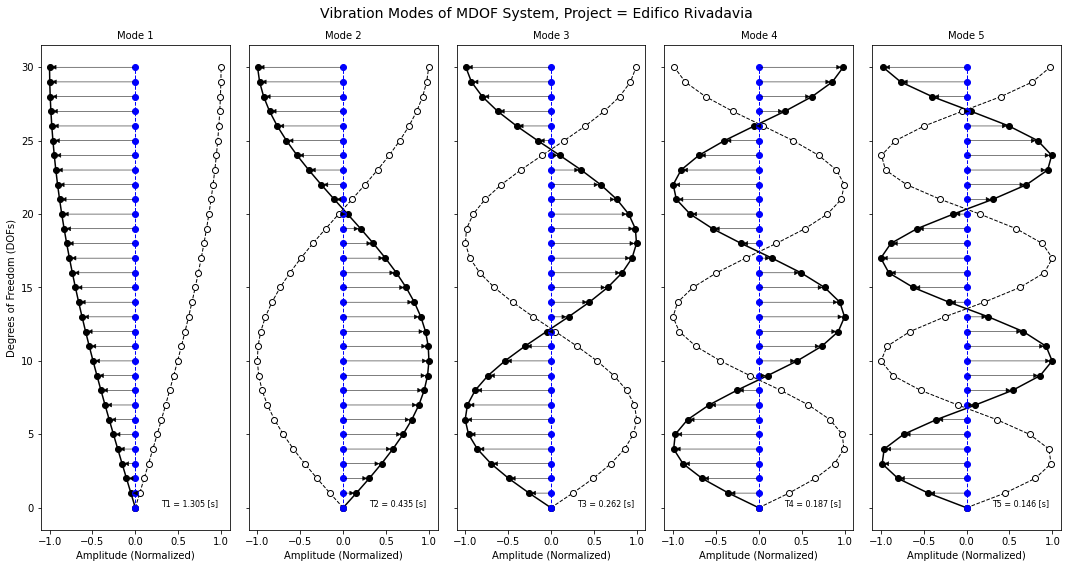

In [8]:
plotvibration = Plot_vibration(v = v_normalized,num_modes_to_plot= len(T), T = T, plotmax= 5, project= ProjecName)
plotvibration.plot_vibration_modes_subplots()

#### Calculate the modal excitation factor for each structural period (**$\{L\}$**).

$$ \{L\} = [\mathbf{\Phi}_n]^\mathrm{T} [M] \{r\} $$


In [9]:
L = np.dot(np.dot(v_normalized.T, M), r)                                                                                          # Calculation of the modal excitation factor vector {L} using the formula {L} = [Φ_n]^T [M] {r}.
L_frame = pd.DataFrame(L, columns= ['Modal excitation factor'])                                                                   # Convert the modal excitation factor vector {L} into a DataFrame for better visualization.
L_frame.head(len(L)) 

,Modal excitation factor
0,-70.229636
1,23.368456
2,-13.971314
3,-9.926101
4,-7.664776
5,6.214211
6,5.200105
7,4.447763
8,-3.864682
9,3.397291


#### Effective Modal Mass.

$$ 
   \{M_{e,i}\} = \frac{\{L_i\}^2}{\sum M_{\text{total}}} 
   $$

In [10]:
Mtotal = np.sum(np.diag(M))                                                                                                       # Calculate the total mass by summing the diagonal elements of the mass matrix M
M_e = []                                                                                                                          # Initialize a list to store the effective modal masses

for i in np.arange(0, len(T), 1):                                                                                                 # Iterate through each mode
    M_e.append(L[i]**2 / Mtotal * 100)                                                                                            # Calculate the effective modal mass for each mode and append to the list in "%"

M_e_frame = pd.DataFrame(M_e, columns= ['Effective Modal Mass [%]'])                                                              # Create a DataFrame from the effective modal mass array
M_e_frame.head(len(M_e))                                                                                                          # Display the DataFrame with effective modal masses

,Effective Modal Mass [%]
0,82.371469
1,9.120025
2,3.259947
3,1.645483
4,0.981149
5,0.644923
6,0.451606
7,0.330384
8,0.249439
9,0.192753


#### Cumulative Effective Mass.

$$ 
   \{M_{e,\text{cumulative}}\} = \sum_{i=1}^{N} \{M_{e,i}\} 
   $$

In [11]:
M_e_acum = np.zeros(len(M_e))                                                                                                     # Initialize an array of zeros to store the cumulative effective modal masses
M_e_acum[0] = M_e[0]                                                                                                              # Set the first element of the cumulative array to the first effective modal mass

for i in np.arange(1, len(M_e), 1):                                                                                               # Loop through the remaining effective modal masses
    M_e_acum[i] = M_e_acum[i - 1] + M_e[i]                                                                                        # Add the current effective modal mass to the cumulative total

M_e_acum_frame = pd.DataFrame(M_e_acum, columns= ['Cumulative Effective Mass [%]'])                                               # Create a DataFrame from the cumulative effective modal mass array
M_e_acum_frame.head(len(M_e_acum))                                                                                                # Display the DataFrame with cumulative effective modal masses

,Cumulative Effective Mass [%]
0,82.371469
1,91.491493
2,94.751440
3,96.396923
4,97.378072
5,98.022995
6,98.474601
7,98.804985
8,99.054424
9,99.247177


#### Spectral Analisys

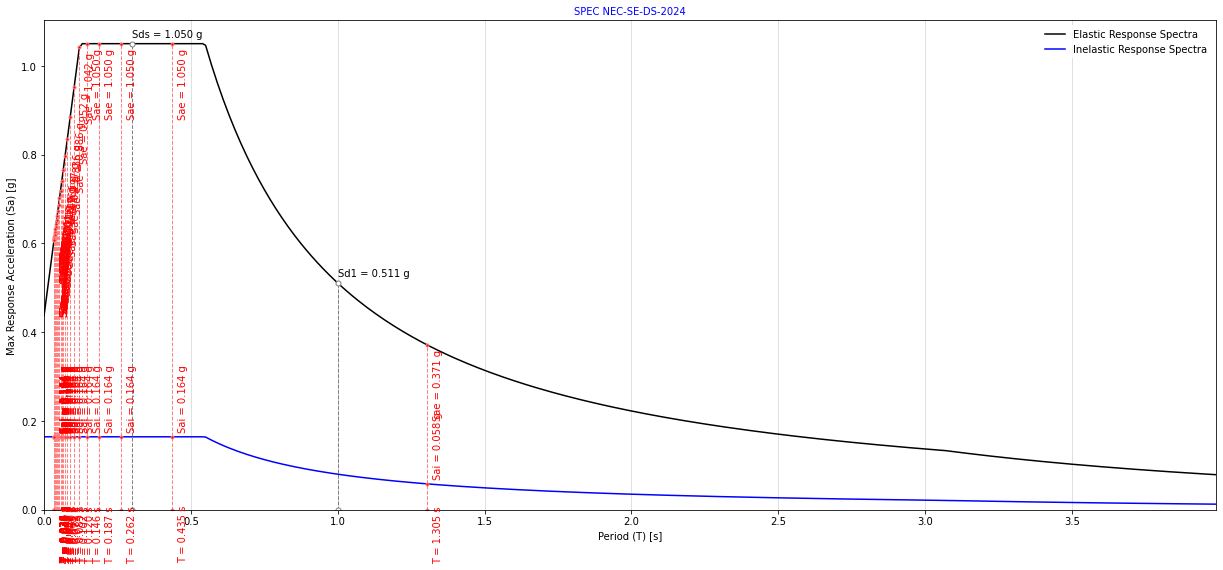

,Period [s],Sae [g],Sai [g]
0,1.304924,0.370987,0.057967
1,0.435359,1.050000,0.164062
2,0.261678,1.050000,0.164062
3,0.187410,1.050000,0.164062
4,0.146281,1.050000,0.164062
5,0.120218,1.041764,0.164062
6,0.102267,0.951538,0.164062
7,0.089187,0.885790,0.164062
8,0.079259,0.835890,0.164062
9,0.071491,0.796844,0.164062


In [12]:
Spec = SpecNec2024_Sae_Sai_modal(Tfind = T, fads = fads, I = I, z = z, n = 2.4, R = R, r = rr, Tf = 4, dT = 0.01)
Resul, SaeF, SaiF, Tl, Sds, Sd1 = Spec.plot_SpecNEC_modal()
Resul

#### Calculate the maximum modal displacement ($ q_n^{\mathrm{max}} $) and the maximum modal lateral force ($ Q_n^{\mathrm{max}} $) for each mode.

   $$ \{q_n^{\mathrm{max}}\} = \frac{L_n \cdot S_{ai,n} \cdot g }{\omega_n^2} \cdot \{\mathbf{\Phi}_n\} $$

   $$ \{Q_n^{\mathrm{max}}\} = L_n \cdot S_{ai,n} \cdot g \cdot [M] \cdot \{\mathbf{\Phi}_n\} $$

In [13]:
qn = []                                                                                                                          # Initialize a list to store the maximum modal displacements
Qn = []                                                                                                                          # Initialize a list to store the maximum modal lateral force
g = 9.8                                                                                                                          # Gravitational acceleration in m/s^2

Cd = 5.5                                                                                                                         # Inelastic displacement amplification factor based on the response modification coefficient (R)

for i in np.arange(0, len(M_e_acum), 1):                                                                                         # Loop through the modes to calculate the maximum modal displacement
    qn.append(((L[i] * SaiF[i] * g )/ (w2[i])) * v_normalized[:, i] * Cd)                                                        # Calculate and append the maximum modal displacement for each mode
    Qn.append(L[i] * SaiF[i] * g * np.dot(M, v_normalized[:, i]))                                                                # Calculate and append the maximum modal lateral force for each mode

qn_array = np.array(qn).T                                                                                                        # Convert the list to a NumPy array and transpose for column-wise representation
Qn_array = np.array(Qn).T                                                                                                        # Convert the list to a NumPy array and transpose for column-wise representation


qn_columns = [f'qn{i + 1}' for i in range(qn_array.shape[1])]                                                                    # Generate column names as qn1, qn2, ..., qnN
Qn_columns = [f'Qn{i + 1}' for i in range(qn_array.shape[1])]                                                                    # Generate column names as qn1, qn2, ..., qnN

rows = pd.Index(f'd{i + 1}' for i in range(len(T)))

qn_frame = pd.DataFrame(qn_array, columns=qn_columns, index = rows)                                                              # Create a DataFrame with appropriate column names
qn_frame.head(len(qn))                                                                                                           # Display the DataFrame with all modal displacements

,qn1,qn2,qn3,qn4,qn5,qn6,qn7,qn8,qn9,qn10,...,qn21,qn22,qn23,qn24,qn25,qn26,qn27,qn28,qn29,qn30
d1,0.008831,0.002767,0.000989,0.000499,0.000298,0.000196,0.000137,0.000100,0.000076,0.000058,...,5.311253e-06,4.142591e-06,3.166917e-06,2.356532e-06,1.689837e-06,1.150018e-06,7.240914e-07,4.022128e-07,1.771750e-07,4.405868e-08
d2,0.017639,0.005469,0.001913,0.000934,0.000533,0.000330,0.000215,0.000144,0.000097,0.000065,...,-5.468389e-06,-4.972885e-06,-4.302404e-06,-3.540132e-06,-2.754530e-06,-2.001687e-06,-1.326994e-06,-7.663242e-07,-3.468575e-07,-8.765032e-08
d3,0.026400,0.008040,0.002711,0.001249,0.000655,0.000362,0.000200,0.000105,0.000049,0.000014,...,3.189222e-07,1.827002e-06,2.678100e-06,2.961681e-06,2.800203e-06,2.334059e-06,1.707803e-06,1.057842e-06,5.018719e-07,1.303129e-07
d4,0.035091,0.010420,0.003330,0.001404,0.000639,0.000280,0.000099,0.000007,-0.000035,-0.000049,...,5.140032e-06,2.779700e-06,6.640800e-07,-9.090943e-07,-1.809959e-06,-2.060908e-06,-1.802784e-06,-1.249152e-06,-6.356628e-07,-1.715940e-07
d5,0.043689,0.012551,0.003729,0.001378,0.000489,0.000111,-0.000045,-0.000095,-0.000093,-0.000069,...,-5.611025e-06,-5.163833e-06,-3.580284e-06,-1.595982e-06,1.501338e-07,1.253096e-06,1.596039e-06,1.322130e-06,7.425724e-07,2.110563e-07
d6,0.052171,0.014383,0.003883,0.001174,0.000235,-0.000093,-0.000170,-0.000143,-0.000085,-0.000028,...,6.369987e-07,3.419113e-06,4.199903e-06,3.306680e-06,1.565233e-06,-1.201943e-07,-1.122171e-06,-1.269864e-06,-8.180796e-07,-2.482813e-07
d7,0.060515,0.015873,0.003780,0.000820,-0.000068,-0.000268,-0.000221,-0.000110,-0.000015,0.000038,...,4.955180e-06,1.059432e-06,-2.125480e-06,-3.371524e-06,-2.701552e-06,-1.043889e-06,4.604903e-07,1.097305e-06,8.589914e-07,2.828744e-07
d8,0.068698,0.016985,0.003429,0.000360,-0.000357,-0.000359,-0.000177,-0.000015,0.000065,0.000070,...,-5.738781e-06,-4.690886e-06,-1.312339e-06,1.758239e-06,2.838450e-06,1.937158e-06,2.782613e-07,-8.207987e-07,-8.635776e-07,-3.144690e-07
d9,0.076699,0.017691,0.002851,-0.000146,-0.000571,-0.000338,-0.000056,0.000089,0.000099,0.000041,...,9.533860e-07,4.571641e-06,3.908354e-06,7.301853e-07,-1.925282e-06,-2.327870e-06,-9.704415e-07,4.665389e-07,8.316443e-07,3.427302e-07
d10,0.084497,0.017977,0.002085,-0.000633,-0.000664,-0.000211,0.000088,0.000142,0.000061,-0.000025,...,4.757188e-06,-7.970424e-07,-3.997342e-06,-2.855170e-06,2.998695e-07,2.114664e-06,1.500203e-06,-6.808419e-08,-7.645419e-07,-3.673583e-07


In [14]:
Qn_frame = pd.DataFrame(Qn_array, columns=Qn_columns, index = rows)                                         # Create a DataFrame with appropriate column names
Qn_frame.head(len(Qn))  

,Qn1,Qn2,Qn3,Qn4,Qn5,Qn6,Qn7,Qn8,Qn9,Qn10,...,Qn21,Qn22,Qn23,Qn24,Qn25,Qn26,Qn27,Qn28,Qn29,Qn30
d1,7.430010,20.917699,20.696114,20.366676,19.932877,19.399315,18.771646,18.056523,17.261528,16.395087,...,5.105115,4.206352,3.374531,2.618469,1.946182,1.364796,0.880473,0.498348,0.222470,0.055765
d2,14.840318,41.337051,40.027433,38.114883,35.659402,32.737335,29.438439,25.862437,22.115234,18.304909,...,-5.256153,-5.049425,-4.584458,-3.933632,-3.172388,-2.375524,-1.613585,-0.949487,-0.435533,-0.110940
d3,22.211271,60.771580,56.719160,50.962798,43.860872,35.846612,27.394880,18.986359,11.072208,4.042114,...,0.306544,1.855122,2.853669,3.290884,3.224989,2.769970,2.076637,1.310682,0.630177,0.164938
d4,29.523324,78.758275,69.670568,57.258611,42.806564,27.755655,13.523297,1.331808,-7.929672,-13.791939,...,4.940540,2.822484,0.707615,-1.010144,-2.084528,-2.445805,-2.192130,-1.547718,-0.798172,-0.217188
d5,36.757087,94.868616,78.027582,56.192893,32.718966,10.992475,-6.187110,-17.078805,-21.231596,-19.440641,...,-5.393253,-5.243312,-3.814997,-1.773381,0.172909,1.487126,1.940735,1.638139,0.932413,0.267135
d6,43.893377,108.718787,81.239102,47.902660,15.726821,-9.205292,-23.226167,-25.793855,-19.271959,-7.913292,...,0.612276,3.471738,4.475237,3.674230,1.802676,-0.142642,-1.364526,-1.573381,-1.027224,-0.314251
d7,50.913269,119.978820,79.093345,33.453755,-4.584090,-26.526876,-30.237086,-19.865846,-3.459375,10.605550,...,4.762863,1.075739,-2.264821,-3.746282,-3.111373,-1.238847,0.559942,1.359577,1.078595,0.358036
d8,57.798148,128.380452,71.731814,14.703823,-23.927640,-35.560167,-24.192829,-2.660084,14.839855,19.754255,...,-5.516051,-4.763085,-1.398372,1.953674,3.269039,2.298943,0.338357,-1.016982,-1.084353,-0.398025
d9,64.529757,133.723521,59.639960,-5.936526,-38.221839,-33.482723,-7.703066,16.055797,22.471995,11.449828,...,0.916384,4.642005,4.164574,0.811348,-2.217345,-2.762625,-1.180027,0.578049,1.044256,0.433796
d10,71.090245,135.880734,43.615176,-25.813638,-44.450243,-20.943641,12.112575,25.656872,13.950958,-6.970666,...,4.572555,-0.809310,-4.259397,-3.172533,0.345359,2.509600,1.824201,-0.084357,-0.959999,-0.464968


#### Determination of the Number of Vibration Modes Required to Achieve at Least 90% Mass Participation

In [15]:
threshold_modal_shape = np.where(M_e_acum >= 90)[0][0] + 1                                                                       # Find the first modal shape where the cumulative effective mass reaches at least 90% of the total mass

print('\x1b[1;34m')
print('='*120)               
print('\x1b[1;34mThe modal shape where at least 90% of the mass participation is reached:', threshold_modal_shape)               # Print the modal shape where the condition is met
print(f'\x1b[1;34mThe cumulative effective mass at this modal shape is: {M_e_acum[threshold_modal_shape - 1]:.3f} %')            # Print the cumulative mass at the identified modal shape
print('='*120)  


The modal shape where at least 90% of the mass participation is reached: 2
The cumulative effective mass at this modal shape is: 91.491 %



#### Superimpose the necessary modal responses (displacements and forces) to achieve at least 90% mass participation using combination rules


* Square Root of Summary of Squares (SRSS)
$$ q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \left( q_n^{\mathrm{max}} \mathbf{\Phi}_n \right)^2} $$

$$ Q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \left( Q_n^{\mathrm{max}} \mathbf{\Phi}_n \right)^2} $$

In [16]:
qtotal_SRSS = qn_array[:, 0] ** 2                                                                                                # Initialize qtotal with the square of the first column (modal displacements)
Qtotal_SRSS = Qn_array[:, 0] ** 2                                                                                                # Initialize Qtotal with the square of the first column (modal forces)

for i in np.arange(1, threshold_modal_shape, 1):                                                                                 # Iterate through modes up to the threshold for 90% mass participation
    qtotal_SRSS = qtotal_SRSS + qn_array[:, i] ** 2                                                                              # Add the squared values of each subsequent modal displacement
    Qtotal_SRSS = Qtotal_SRSS + Qn_array[:, i] ** 2                                                                              # Add the squared values of each subsequent modal force

qtotal_SRSS = qtotal_SRSS ** 0.5                                                                                                 # Apply the square root to finalize the SRSS for modal displacements
Qtotal_SRSS = Qtotal_SRSS ** 0.5                                                                                                 # Apply the square root to finalize the SRSS for modal forces

# Create a DataFrame to store the SRSS results
Resul_SRSS = pd.DataFrame({'SRSS of maximum modal inelastic displacement [m]': qtotal_SRSS,
                           'SRSS of maximum modal lateral force [T]': Qtotal_SRSS}, index= rows)   
Resul_SRSS.head(len(L))                                                                                                          # Display the DataFrame with SRSS results

,SRSS of maximum modal inelastic displacement [m],SRSS of maximum modal lateral force [T]
d1,0.009255,22.198090
d2,0.018467,43.920233
d3,0.027597,64.703366
d4,0.036605,84.110003
d5,0.045456,101.740541
d6,0.054117,117.245056
d7,0.062562,130.334486
d8,0.070767,140.791215
d9,0.078713,148.479189
d10,0.086388,153.353829


* Complete Quadratic Combination (CQC)</u>.  

   $$ q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \sum_{m=1}^{N} q_n^{\mathrm{max}} q_m^{\mathrm{max}} \rho_{nm} \mathbf{\Phi}_n \mathbf{\Phi}_m} $$

   $$ Q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \sum_{m=1}^{N} Q_n^{\mathrm{max}} Q_m^{\mathrm{max}} \rho_{nm} \mathbf{\Phi}_n \mathbf{\Phi}_m} $$

In [17]:
qtotal_cqc = 0                                                                                                                   # Initialize total displacement for CQC
Qtotal_cqc = 0                                                                                                                   # Initialize total lateral force for CQC

rho = np.identity(len(L))                                                                                                        # Define the modal correlation coefficient matrix (identity as placeholder)

for n in np.arange(0, len(L), 1):                                                                                                # Loop through each mode (row index)
    for m in np.arange(0, len(L), 1):                                                                                            # Loop through each mode (column index)
        qtotal_cqc += qn_array[:, n] * qn_array[:, m] * rho[n, m]                                                                # Add contributions of displacement modes using correlation coefficients
        Qtotal_cqc += Qn_array[:, n] * Qn_array[:, m] * rho[n, m]                                                                # Add contributions of force modes using correlation coefficients

qtotal_cqc = qtotal_cqc ** 0.5                                                                                                   # Compute the square root for total displacement
Qtotal_cqc = Qtotal_cqc ** 0.5                                                                                                   # Compute the square root for total lateral force

qtotal = qtotal_cqc                                                                                                              # se graba esa variable para usos porsteriores

# Create a DataFrame to store the CQC results
Resul_cqc = pd.DataFrame({"CQC of maximum modal inelastic displacement [m]": qtotal_cqc,
                          "CQC of maximum modal lateral force [T]": Qtotal_cqc}, index = rows)

Resul_cqc.head(len(L))                                                                                                           # Display the DataFrame with CQC results

,CQC of maximum modal inelastic displacement [m],CQC of maximum modal lateral force [T]
d1,0.009330,68.393079
d2,0.018602,101.358299
d3,0.027769,122.929770
d4,0.036790,138.609448
d5,0.045633,150.346829
d6,0.054270,159.129281
d7,0.062683,165.557323
d8,0.070853,170.043889
d9,0.078768,172.901244
d10,0.086418,174.385119


#### Base Shear
$$ V_{\mathrm{total}, i} = \sum_{j=i}^{N} Q_{\mathrm{total}, j} $$

In [18]:
VD_srss = np.sum(Qtotal_SRSS)                                                                                                    # Summation of all floor forces (SRSS)
VD_cqc = np.sum(Qtotal_cqc)                                                                                                      # Summation of all floor forces (CQC)

Result_Basal = pd.DataFrame({
    "SRSS Base Shear [T]": [VD_srss],                                                                                            # Convert scalar to list
    "CQC Base Shear [T]": [VD_cqc]                                                                                               # Convert scalar to list
})

Result_Basal.head()                                                                                                              # Display DataFrame

,SRSS Base Shear [T],CQC Base Shear [T]
0,4065.966561,5001.617614


#### Minimum Code-Prescribed Shear

Although this exercise does not aim to perform a modal spectral analysis based on regulatory constraints, to better align this example with real-world procedures, the following expressions outline the minimum shear force requirements as prescribed in **[ASCE 7-16](https://www.asce.org/publications-and-news/asce-7)**.


The total seismic base shear force $V$ is determined using the following equation:

$$ V = C_s W $$

where:

- $C_s$ = Seismic response coefficient, defined as:

$$ C_s = \frac{S_{DS}}{\frac{R}{I_e}} $$

- $S_{DS}$ = Design spectral response acceleration for short periods.

- $R$ = Response modification factor, obtained from Table **12.2-1 ASCE**.

- $I_e$ = Importance factor, determined from Section **11.5.1 ASCE**.

- $W$ = Effective seismic weight of the structure, as defined in Section **12.7.2 ASCE**.


Additionally, the seismic response coefficient $C_s$ must satisfy the following limits:

- **For structures where the period $T \leq T_L$:**

$$ C_s = \frac{S_{D1}}{T \left( \frac{R}{I_e} \right)} $$

- **For structures where $T > T_L$:**

$$ C_s = \frac{S_{D1} T_L}{T^2 \left( \frac{R}{I_e} \right)}  $$

- **Lower bound condition for $C_s$:**

$$ C_s = 0.044 S_{DS} I_e \geq 0.01 $$

In [19]:
Csmin = np.maximum(0.044 * Sds * I, 0.01)                                                                                        # Compute the minimum seismic coefficient (Csmin) as per ASCE 7-16 Equation 12.8-5

if T[0] <= Tl:                                                                                                               # Check if the first fundamental period (T1) is less than or equal to the characteristic period (Tl)
    Cs = np.maximum(Sd1 / (T[0] * (R / I)), Csmin)                                                                 # Compute Cs using ASCE 7-16 Equation 12.8-3 and ensure it is not less than Csmin
else:
    if T[0] > Tl:                                                                                                            # If the first fundamental period (T1) is greater than the characteristic period (Tl)
        Cs = np.maximum((Sd1 * Tl) / (T[0]**2 * (R / I)), Csmin )                                                              # Compute Cs using ASCE 7-16 Equation 12.8-4 and ensure it is not less than 0.01

total_weight = Mtotal * g                                                                                                        # Compute the total seismic weight of the building in tons (W = Mtotal * g)
VD_ASCE = total_weight * Cs                                                                                                      # Compute the ASCE 7-16 minimum base shear force (V = Cs * W)

VD_ASCE_frame = pd.DataFrame({'Minimum Base Shear ASCE [T]': [VD_ASCE]})                                                         # Create a DataFrame to store the minimum base shear force value
VD_ASCE_frame.head()                                                                                                             # Display the first row of the DataFrame

,Minimum Base Shear ASCE [T]
0,3587.44763


In [20]:
V = np.maximum(VD_cqc, VD_srss)                                                                                                 # Compute the base shear (V) as the maximum value between CQC and SRSS base shear forces

fscale = VD_ASCE / V                                                                                                            # Compute the scaling factor to adjust results to ASCE 7-16 minimum base shear

q_ASCE = qtotal_cqc * fscale                                                                                                        # Scale the maximum modal inelastic displacement to match ASCE base shear
Q_ASCE = Qtotal_cqc * fscale                                                                                                    # Scale the modal lateral force at each floor according to ASCE

Result_ASCE_df = pd.DataFrame({'ASCE of maximum modal lateral force [T]': Q_ASCE,                                                  # Create a DataFrame with ASCE-adjusted maximum modal lateral forces
                             'ASCE of maximum modal inelastic displacement [m]': q_ASCE})                                            


VD_ASCE = np.sum(Q_ASCE)
print(f'V_ASCE = {VD_ASCE} [T]')
Result_ASCE_df.head(len(Q_ASCE))                                                                                                   # Display the full DataFrame with ASCE-adjusted results


V_ASCE = 3587.4476299279636 [T]


,ASCE of maximum modal lateral force [T],ASCE of maximum modal inelastic displacement [m]
0,49.055448,0.006692
1,72.699998,0.013343
2,88.172296,0.019918
3,99.418663,0.026388
4,107.837387,0.032730
5,114.136667,0.038926
6,118.747228,0.044960
7,121.965251,0.050820
8,124.014710,0.056497
9,125.079031,0.061984


#### Calculate the inelastic story drifts for each floor.

   $$ \Delta_s = \frac{\delta_{i+1} - \delta_i}{h} $$


In [21]:
ds_SRSS = []                                                                                                                     # Initialize a list to store SRSS inelastic story drifts (as percentages)
ds_CQC = []                                                                                                                      # Initialize a list to store CQC inelastic story drifts (as percentages)
ds_ASCE = []                                                                                                                     # Initialize a list to store ASCE inelastic story drifts (as percentages)

qtotal_SRSS = np.insert(qtotal_SRSS, 0, 0)                                                                                       # Prepend a zero to the beginning of the qtotal_SRSS array
qtotal_cqc = np.insert(qtotal_cqc, 0, 0)
q_ASCE = np.insert(q_ASCE, 0, 0)                                                                                                 # Prepend a zero to the beginning of the q_ASCE array
H = np.insert(H, 0, 0)                                                                                                           # Prepend a zero to the beginning of the H array to include ground level

for i in np.arange(1, len(H), 1):                                                                                                # Iterate through each floor starting from the second one
    ds_SRSS.append(np.abs((qtotal_SRSS[i] - qtotal_SRSS[i-1]) / H[i] * 100))                                                     # Calculate and append SRSS inelastic drift percentage for the i-th story
    ds_CQC.append(np.abs((qtotal_cqc[i] - qtotal_cqc[i-1]) / H[i] * 100))                                                        # Calculate and append CQC inelastic drift percentage for the i-th story
    ds_ASCE.append(np.abs((q_ASCE[i] - q_ASCE[i-1]) / H[i] * 100))                                                               # Calculate and append ASCE inelastic drift percentage for the i-th story
    
Resul_ds = pd.DataFrame({"SRSS inelastic drift [ % ]": ds_SRSS,                                                                  # Create a DataFrame with SRSS drift percentages as a column
                         "CQC inelastic drift [ % ]": ds_CQC,                                                                    # Add CQC drift percentages as a second column
                         "ASCE inelastic drift [ % ]": ds_ASCE})                                                                 # Add ASCE drift percentages as a third column

Resul_ds.head(len(L))                                                                                                            # Display the DataFrame containing the story drifts

,SRSS inelastic drift [ % ],CQC inelastic drift [ % ],ASCE inelastic drift [ % ]
0,0.257074,0.259164,0.185888
1,0.255908,0.257571,0.184745
2,0.253606,0.254631,0.182636
3,0.250227,0.250581,0.179731
4,0.245854,0.245626,0.176177
5,0.240595,0.239939,0.172098
6,0.234568,0.233670,0.167601
7,0.227905,0.226945,0.162778
8,0.220738,0.219867,0.157701
9,0.213192,0.212520,0.152432


#### Summary

In [22]:
H_cumulative = np.cumsum(H)                                                                                                      # Compute the cumulative height by summing the story heights sequentially
Qtotal_SRSS = np.insert(Qtotal_SRSS, 0, 0)                                                                                       # Prepend a zero to the beginning of the Qtotal_SRSS array
Qtotal_cqc = np.insert(Qtotal_cqc, 0, 0)                                                                                         # Prepend a zero to the beginning of the Qtotal_cqc array

Q_ASCE = np.insert(Q_ASCE, 0, 0)                                                                                                 # Prepend a zero to the beginning of the Q_ASCE array
ds_ASCE = np.insert(ds_ASCE, 0, 0)                                                                                               # Prepend a zero to the beginning of the ds_ASCE array
M_overturning_ASCE = np.cumsum(Q_ASCE * H_cumulative)[::-1]                                                                      # Overturning moment ASCE [T·m] (Inverted)

M_overturning_CQC = np.cumsum(Qtotal_cqc * H_cumulative)[::-1]                                                                   # Overturning moment CQC [T·m] (Inverted)
M_overturning_SRSS = np.cumsum(Qtotal_SRSS * H_cumulative)[::-1]                                                                 # Overturning moment SRSS [T·m] (Inverted)
Vtotal_srss = np.cumsum(Qtotal_SRSS[::-1])[::-1]                                                                             # Compute floor shear force profile for SRSS
Vtotal_cqc = np.cumsum(Qtotal_cqc[::-1])[::-1]                                                                               # Compute floor shear force profile for CQC
Vtotal_ASCE = np.cumsum(Q_ASCE[::-1])[::-1]                                                                                  # Compute floor shear force profile for ASCE
ds_SRSS = np.insert(ds_SRSS, 0, 0)                                                                                               # Prepend a zero to the beginning of the ds_SRSS array
ds_CQC = np.insert(ds_CQC, 0, 0)                                                                                                 # Prepend a zero to the beginning of the ds_CQC array

Summary= pd.DataFrame({"Height": H_cumulative,                                                                                   # Create a DataFrame with all the Results
                           "CQC of maximum modal lateral force [T]": Qtotal_cqc,
                           'SRSS of maximum modal lateral force [T]': Qtotal_SRSS,
                           'ASCE of maximum modal lateral force [T]': Q_ASCE,
                           "CQC Floor Shear Force [T]": Vtotal_cqc,
                           "SRSS Floor Shear Force [T]": Vtotal_srss,
                           "ASCE Floor Shear Force [T]": Vtotal_ASCE,
                           "CQC Overturning Moment [T·m]": M_overturning_CQC, 
                           "SRSS Overturning Moment [T·m]": M_overturning_SRSS,
                           "ASCE Overturning Moment [T·m]": M_overturning_ASCE,
                           'CQC of maximum modal inelastic displacement [m]': qtotal_cqc,
                           'SRSS of maximum modal inelastic displacement [m]': qtotal_SRSS,
                           'ASCE of maximum modal inelastic displacement [m]': q_ASCE,
                           "SRSS inelastic drift [ % ]": ds_SRSS,
                           "CQC inelastic drift [ % ]": ds_CQC,
                           "ASCE inelastic drift [ % ]": ds_ASCE})

print('='*120)
print(f'V_CQC = {VD_cqc} [T]')
print(f'V_SRSS = {VD_srss} [T]')
print(f'V_ASCE = {VD_ASCE} [T]')
print('='*120)

Summary.head(len(ds_CQC))

V_CQC = 5001.617614226296 [T]
V_SRSS = 4065.9665606988165 [T]
V_ASCE = 3587.4476299279636 [T]


,Height,CQC of maximum modal lateral force [T],SRSS of maximum modal lateral force [T],ASCE of maximum modal lateral force [T],CQC Floor Shear Force [T],SRSS Floor Shear Force [T],ASCE Floor Shear Force [T],CQC Overturning Moment [T·m],SRSS Overturning Moment [T·m],ASCE Overturning Moment [T·m],CQC of maximum modal inelastic displacement [m],SRSS of maximum modal inelastic displacement [m],ASCE of maximum modal inelastic displacement [m],SRSS inelastic drift [ % ],CQC inelastic drift [ % ],ASCE inelastic drift [ % ]
0,0.0,0.000000,0.000000,0.000000,5001.617614,4065.966561,3587.447630,301355.860991,256376.309375,216149.744475,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,3.6,68.393079,22.198090,49.055448,5001.617614,4065.966561,3587.447630,276038.436786,234997.880191,197990.632670,0.009330,0.009255,0.006692,0.257074,0.259164,0.185888
2,7.2,101.358299,43.920233,72.699998,4933.224535,4043.768471,3538.392182,252934.836478,214590.781290,181419.402609,0.018602,0.018467,0.013343,0.255908,0.257571,0.184745
3,10.8,122.929770,64.703366,88.172296,4831.866236,3999.848238,3465.692184,231849.036689,195374.738165,166295.455056,0.027769,0.027597,0.019918,0.253606,0.254631,0.182636
4,14.4,138.609448,84.110003,99.418663,4708.936466,3935.144872,3377.519888,212581.932529,177520.190593,152475.980540,0.036790,0.036605,0.026388,0.250227,0.250581,0.179731
5,18.0,150.346829,101.740541,107.837387,4570.327018,3851.034869,3278.101225,194934.067680,161139.736937,139817.917528,0.045633,0.045456,0.032730,0.245854,0.245626,0.176177
6,21.6,159.129281,117.245056,114.136667,4419.980190,3749.294328,3170.263838,178709.195464,146281.234975,128180.506620,0.054270,0.054117,0.038926,0.240595,0.239939,0.172098
7,25.2,165.557323,130.334486,118.747228,4260.850909,3632.049272,3056.127172,163718.655550,132922.758531,117428.429786,0.062683,0.062562,0.044960,0.234568,0.233670,0.167601
8,28.8,170.043889,140.791215,121.965251,4095.293586,3501.714786,2937.379944,149786.342053,120970.284244,107435.373761,0.070853,0.070767,0.050820,0.227905,0.226945,0.162778
9,32.4,172.901244,148.479189,124.014710,3925.249697,3360.923571,2815.414693,136753.789331,110260.291707,98087.677879,0.078768,0.078713,0.056497,0.220738,0.219867,0.157701


#### Plots

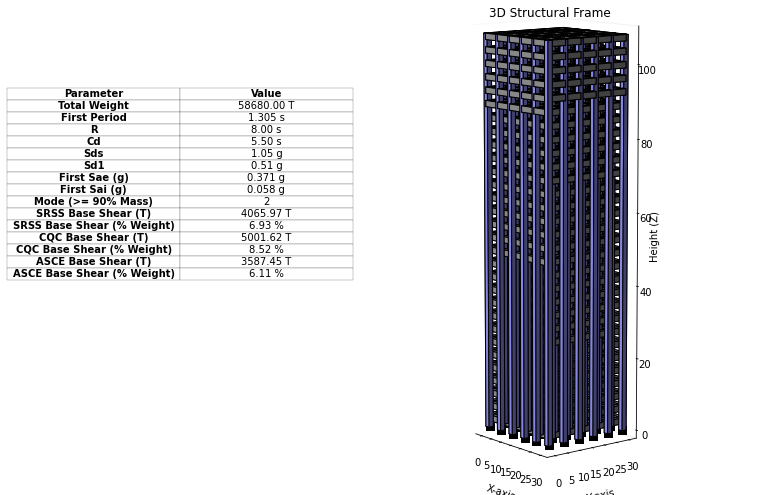

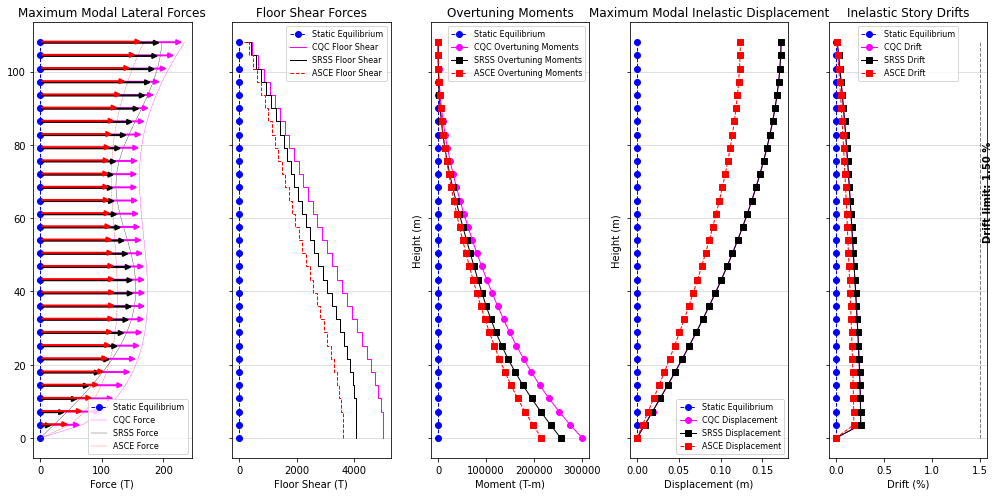

,Height,CQC of maximum modal lateral force [T],SRSS of maximum modal lateral force [T],ASCE of maximum modal lateral force [T],CQC Floor Shear Force [T],SRSS Floor Shear Force [T],ASCE Floor Shear Force [T],CQC Overturning Moment [T·m],SRSS Overturning Moment [T·m],ASCE Overturning Moment [T·m],CQC of maximum modal inelastic displacement [m],SRSS of maximum modal inelastic displacement [m],ASCE of maximum modal inelastic displacement [m],SRSS inelastic drift [ % ],CQC inelastic drift [ % ],ASCE inelastic drift [ % ]
0,0.0,0.000000,0.000000,0.000000,5001.617614,4065.966561,3587.447630,301355.860991,256376.309375,216149.744475,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,3.6,68.393079,22.198090,49.055448,5001.617614,4065.966561,3587.447630,276038.436786,234997.880191,197990.632670,0.009330,0.009255,0.006692,0.257074,0.259164,0.185888
2,7.2,101.358299,43.920233,72.699998,4933.224535,4043.768471,3538.392182,252934.836478,214590.781290,181419.402609,0.018602,0.018467,0.013343,0.255908,0.257571,0.184745
3,10.8,122.929770,64.703366,88.172296,4831.866236,3999.848238,3465.692184,231849.036689,195374.738165,166295.455056,0.027769,0.027597,0.019918,0.253606,0.254631,0.182636
4,14.4,138.609448,84.110003,99.418663,4708.936466,3935.144872,3377.519888,212581.932529,177520.190593,152475.980540,0.036790,0.036605,0.026388,0.250227,0.250581,0.179731
5,18.0,150.346829,101.740541,107.837387,4570.327018,3851.034869,3278.101225,194934.067680,161139.736937,139817.917528,0.045633,0.045456,0.032730,0.245854,0.245626,0.176177
6,21.6,159.129281,117.245056,114.136667,4419.980190,3749.294328,3170.263838,178709.195464,146281.234975,128180.506620,0.054270,0.054117,0.038926,0.240595,0.239939,0.172098
7,25.2,165.557323,130.334486,118.747228,4260.850909,3632.049272,3056.127172,163718.655550,132922.758531,117428.429786,0.062683,0.062562,0.044960,0.234568,0.233670,0.167601
8,28.8,170.043889,140.791215,121.965251,4095.293586,3501.714786,2937.379944,149786.342053,120970.284244,107435.373761,0.070853,0.070767,0.050820,0.227905,0.226945,0.162778
9,32.4,172.901244,148.479189,124.014710,3925.249697,3360.923571,2815.414693,136753.789331,110260.291707,98087.677879,0.078768,0.078713,0.056497,0.220738,0.219867,0.157701


In [23]:
TieF = T
from mpl_toolkits.mplot3d import Axes3D                                                                                          # Import Axes3D for 3D plotting
first_period = TieF[0]                                                                                                           # Extract the first natural period (T1) from the period array
first_SaeF = SaeF[0]                                                                                                             # Extract the first (Sai) from the period array
first_SaiF = SaiF[0]                                                                                                             # Extract the first (Sae) from the period array
mode_90_mass = threshold_modal_shape                                                                                             # Identify the mode number at which at least 90% of the mass participation is reached

SRSS_base_shear_tons = VD_srss                                                                                                   # Assign the base shear obtained from SRSS combination in tons
SRSS_base_shear_percent = (SRSS_base_shear_tons / total_weight) * 100                                                            # Compute base shear as a percentage of total building weight

CQC_base_shear_tons = VD_cqc                                                                                                     # Assign the base shear obtained from CQC combination in tons
CQC_base_shear_percent = (CQC_base_shear_tons / total_weight) * 100                                                              # Compute base shear as a percentage of total building weight

ASCE_base_shear_tons = VD_ASCE                                                                                                   # Assign the base shear obtained from ASCE combination in tons
ASCE_base_shear_percent = (ASCE_base_shear_tons / total_weight) * 100                                                            # Compute base shear as a percentage of total building weight

def plot_3d_frame(sto, h, span, LV, total_weight, first_period, mode_90_mass, SRSS_base_shear_tons, SRSS_base_shear_percent,     # Define function to plot the 3D frame 
                  CQC_base_shear_tons, CQC_base_shear_percent , ASCE_base_shear_tons, ASCE_base_shear_percent,
                  first_SaeF, first_SaiF, R, Cd, Sds, Sd1):    
    alpha = 1                                                                                                                    # set value of alpha for column and beams transparency
    fig = plt.figure(figsize=(15, 8))                                                                                            # Create a figure with size 13x8
    ax = fig.add_subplot(111, projection='3d')                                                                                   # Add a 3D subplot for visualization

    x_positions = np.arange(0, (span[0] + 1) * LV, LV)                                                                           # X-coordinates for columns
    y_positions = np.arange(0, (span[1] + 1) * LV, LV)                                                                           # Y-coordinates for columns
    z_positions = np.arange(0, (sto + 1) * h, h)                                                                                 # Z-coordinates for floor levels

    # Draw columns
    for x in x_positions:                                                                                                        # Iterate over X positions
        for y in y_positions:                                                                                                    # Iterate over Y positions
            ax.plot([x, x], [y, y], [0, sto * h], color=(0, 0, 0), linewidth=2, linestyle = '--',                                # Draw vertical columns
                    marker='o', markerfacecolor=(1, 1, 1), markersize=1)                                                         # Add white circular markers at column top
            ax.bar3d(x - C/2, y - C/2, 0, C, C, sto * h, color=(0.6, 0.6, 1), alpha= alpha, shade=True, edgecolor=(0, 0, 0))     # Draw cuboid at column position                                                                 
            ax.plot([x, x], [y, y], [0, 0], color=(0, 0, 0), linewidth=1.0,                                                      # Draw base nodes
                    marker='s', markerfacecolor=(0, 0, 0), markersize=8)                                                         # Add black square markers at column base

    # Draw beams
    for z in z_positions[1:]:                                                                                                    # Iterate over floors (excluding base level)
        for x in x_positions:                                                                                                    # Iterate over X positions
            ax.plot([x, x], [y_positions[0], y_positions[-1]], [z, z], color=(0, 0, 0), linewidth=1.0,                           # Draw beams in Y direction
                    marker='o', markerfacecolor=(1, 1, 1), markersize=1)                                                         # Add white circular markers at beam junctions
        for y in y_positions:                                                                                                    # Iterate over Y positions
            ax.plot([x_positions[0], x_positions[-1]], [y, y], [z, z], color=(0, 0, 0), linewidth=1.0,                           # Draw beams in X direction
                    marker='o', markerfacecolor=(1, 1, 1), markersize=1)                                                         # Add white circular markers at beam junctions
    # Draw beams as solid
    for z in z_positions[1:]:                                                                                                    # Iterate over floors (excluding base level)
        for y in y_positions:                                                                                                    # Iterate over Y positions
            for x in x_positions[:-1]:                                                                                           # Iterate over X positions (excluding last to prevent out-of-bounds)
                ax.bar3d(x, y - C/2, z - C, LV, C, C, color=(0.6, 0.6, 0.6), alpha= alpha, shade=True, edgecolor=(0, 0, 0))      # Draw beams in X direction
        for x in x_positions:                                                                                                    # Iterate over X positions
            for y in y_positions[:-1]:                                                                                           # Iterate over Y positions (excluding last to prevent out-of-bounds)
                ax.bar3d(x - C/2, y, z - C, C, LV, C, color=(0.6, 0.6, 0.6), alpha= alpha, shade=True, edgecolor=(0, 0, 0))      # Draw beams in Y direction



    # Labels and formatting
    ax.view_init(elev=10, azim=-39)                                                                                              # Set the view angle (elevation and azimuth)
    ax.grid(False)                                                                                                               # Disable grid for better visualization
    ax.xaxis.pane.fill = False                                                                                                   # Remove background fill for X-plane
    ax.yaxis.pane.fill = False                                                                                                   # Remove background fill for Y-plane
    ax.zaxis.pane.fill = False                                                                                                   # Remove background fill for Z-plane
    ax.set_xlabel("X-axis", rotation=0, fontsize=10)                                                                             # Set X-axis label
    ax.set_ylabel("Y-axis", rotation=0, fontsize=10)                                                                             # Set Y-axis label
    ax.set_zlabel("Height (Z)", rotation=0, fontsize=10)                                                                         # Set Z-axis label
    ax.set_title("3D Structural Frame")                                                                                          # Set the title of the plot
    ax.set_box_aspect([max(x_positions) / max(z_positions), 
                   max(y_positions) / max(z_positions), 
                   1])                                                                                                           # Adjust aspect ratio to maintain proportionality between X, Y, and Z axes

    # Add table with key structural parameters
    table_data = [["Total Weight", f"{total_weight:.2f} T"],
                  ["First Period", f"{first_period:.3f} s"],
                  ["R", f"{R:.2f} s"],
                  ["Cd", f"{Cd:.2f} s"],
                  ["Sds", f"{Sds:.2f} g"],
                  ["Sd1", f"{Sd1:.2f} g"],
                  ["First Sae (g)", f"{first_SaeF:.3f} g"],
                  ["First Sai (g)", f"{first_SaiF:.3f} g"],
                  ["Mode (>= 90% Mass)", f"{mode_90_mass}"],
                  ["SRSS Base Shear (T)", f"{SRSS_base_shear_tons:.2f} T"],
                  ["SRSS Base Shear (% Weight)", f"{SRSS_base_shear_percent:.2f} %"],
                  ["CQC Base Shear (T)", f"{CQC_base_shear_tons:.2f} T"],
                  ["CQC Base Shear (% Weight)", f"{CQC_base_shear_percent:.2f} %"],
                  ["ASCE Base Shear (T)", f"{ASCE_base_shear_tons:.2f} T"],
                  ["ASCE Base Shear (% Weight)", f"{ASCE_base_shear_percent:.2f} %"]]
    
    ax_table = fig.add_axes([0.01, 0.50, 0.32, 0.2])                                                                             # Adjusted table position to avoid overlap
    ax_table.axis("off")                                                                                                         # Hide axis for the table
    table = ax_table.table(cellText=table_data, colLabels=["Parameter", "Value"], cellLoc="center", loc="center")                # Create table
    table.auto_set_font_size(False)                                                                                              # Disable automatic font resizing
    table.set_fontsize(10)                                                                                                       # Set font size
    table.scale(1.0, 1.0)                                                                                                        # Scale the table for better readability
    
    for key, cell in table.get_celld().items():
        cell.set_linewidth(0.2)                                                                                                  # Make gridlines thinner
        if key[0] == 0 or key[1] == 0:
            cell.set_text_props(fontweight='bold')                                                                               # Make headers bold
    
    plt.show()                                                                                                                   # Display the plot

plot_3d_frame(sto, h, span, LV, total_weight, first_period, mode_90_mass, SRSS_base_shear_tons, SRSS_base_shear_percent,     
                  CQC_base_shear_tons, CQC_base_shear_percent , ASCE_base_shear_tons, ASCE_base_shear_percent,
                  first_SaeF, first_SaiF, R, Cd, Sds, Sd1)



# Function to plot the summary of the results
def plot_summary_subplots(Summary, maxdrift):                                                                                    # Define the function with Summary DataFrame and max drift limit
    fig, axes = plt.subplots(1, 5, figsize=(14, 7), sharey=True)                                                                 # Create 4 subplots in one row with shared Y-axis (height)

    # First subplot: Maximum Modal Lateral Forces
    axes[0].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[0].plot(Summary["CQC of maximum modal lateral force [T]"], Summary["Height"],                                           # Plot CQC modal force vs height
                 linestyle='-', color=(1, 0, 1), linewidth=0.3, label="CQC Force")  
    axes[0].plot(Summary["SRSS of maximum modal lateral force [T]"], Summary["Height"],                                          # Plot SRSS modal force vs height
                 linestyle='-', color=(0, 0, 0), linewidth=0.3, label="SRSS Force")
    axes[0].plot(Summary["ASCE of maximum modal lateral force [T]"], Summary["Height"],                                          # Plot ASCE modal force vs height
                 linestyle='--', color=(1, 0, 0), linewidth=0.3, label="ASCE Force")    
    axes[0].set_xlabel("Force (T)", fontsize=10)                                                                                 # Set X-axis label
    axes[0].set_title("Maximum Modal Lateral Forces", fontsize=12)                                                               # Set subplot title
    axes[0].legend(fontsize=8)                                                                                                   # Add legend
    axes[0].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization

    # Add proportional arrows for forces CQC (Magenta)
    for i in range(len(Summary["Height"])):                                                                                      # Loop through each floor height
        force_value = Summary["CQC of maximum modal lateral force [T]"].iloc[i]                                                  # Get force value at each floor
        axes[0].annotate("", xy=(force_value, Summary["Height"].iloc[i]), xytext=(0, Summary["Height"].iloc[i]),                 # Draw force arrow
                        arrowprops=dict(facecolor=(1, 0, 1), edgecolor=(1, 0, 1), 
                                        arrowstyle='-|>', lw=2.0, alpha=1.0))

    # Add proportional arrows for forces SRSS (Black, shifted slightly down)
    for i in range(len(Summary["Height"])):                                                                                      # Loop through each floor height
        force_value = Summary["SRSS of maximum modal lateral force [T]"].iloc[i]                                                 # Get force value at each floor
        axes[0].annotate("", xy=(force_value, Summary["Height"].iloc[i] - 0.15), xytext=(0, Summary["Height"].iloc[i] - 0.15),   # Draw force arrow (shifted down)
                        arrowprops=dict(facecolor=(0, 0, 0), edgecolor=(0, 0, 0), 
                                        arrowstyle='-|>', lw=2.0, alpha=1.0))
    
    # Add proportional arrows for forces ASCE (Red, shifted slightly up)
    for i in range(len(Summary["Height"])):                                                                                      # Loop through each floor height
        force_value = Summary["ASCE of maximum modal lateral force [T]"].iloc[i]                                                 # Get force value at each floor
        axes[0].annotate("", xy=(force_value, Summary["Height"].iloc[i] + 0.15), xytext=(0, Summary["Height"].iloc[i] + 0.15),   # Draw force arrow (shifted down)
                        arrowprops=dict(facecolor=(1, 0, 0), edgecolor=(1, 0, 0), 
                                        arrowstyle='-|>', lw=2.0, alpha=1.0))

    # Second subplot: Floor Shear Forces (Stepped Plot)
    axes[1].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[1].step(Summary["CQC Floor Shear Force [T]"], Summary["Height"], where='pre',                                           # Step plot for CQC shear force
                 linestyle='-', color=(1, 0, 1), linewidth=1.0, label="CQC Floor Shear")  
    axes[1].step(Summary["SRSS Floor Shear Force [T]"], Summary["Height"], where='pre',                                          # Step plot for SRSS shear force
                 linestyle='-', color=(0, 0, 0), linewidth=1.0, label="SRSS Floor Shear")
    axes[1].step(Summary["ASCE Floor Shear Force [T]"], Summary["Height"], where='pre',                                          # Step plot for ASCE shear force
                 linestyle='--', color=(1, 0, 0), linewidth=1.0, label="ASCE Floor Shear")  
    axes[1].set_xlabel("Floor Shear (T)", fontsize=10)                                                                           # Set X-axis label
    axes[1].set_title("Floor Shear Forces", fontsize=12)                                                                         # Set subplot title
    axes[1].legend(fontsize=8)                                                                                                   # Add legend
    axes[1].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization
    
    # Third subplot: Maximum Modal Inelastic Displacement
    axes[2].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[2].plot(Summary["CQC Overturning Moment [T·m]"], Summary["Height"],                                                     # Plot CQC overtuning moments vs height
                 marker='o', linestyle='-', color=(1, 0, 1), linewidth=1.0, label="CQC Overtuning Moments")  
    axes[2].plot(Summary["SRSS Overturning Moment [T·m]"], Summary["Height"],                                                    # Plot SRSS overtuning moments vs height
                 marker='s', linestyle='-', color=(0, 0, 0), linewidth=1.0, label="SRSS Overtuning Moments")
    axes[2].plot(Summary["ASCE Overturning Moment [T·m]"], Summary["Height"],                                                    # Plot ASCE overtuning moments vs height
                 marker='s', linestyle='--', color=(1, 0, 0), linewidth=1.0, label="ASCE Overtuning Moments")   
    axes[2].set_ylabel("Height (m)", fontsize=10)                                                                                # Set Y-axis label
    axes[2].set_xlabel("Moment (T-m)", fontsize=10)                                                                              # Set X-axis label
    axes[2].set_title("Overtuning Moments", fontsize=12)                                                                         # Set subplot title
    axes[2].legend(fontsize=8)                                                                                                   # Add legend
    axes[2].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization

    # Fourth subplot: Maximum Modal Inelastic Displacement
    axes[3].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[3].plot(Summary["CQC of maximum modal inelastic displacement [m]"], Summary["Height"],                                  # Plot CQC modal displacement vs height
                 marker='o', linestyle='-', color=(1, 0, 1), linewidth=1.0, label="CQC Displacement")  
    axes[3].plot(Summary["SRSS of maximum modal inelastic displacement [m]"], Summary["Height"],                                 # Plot SRSS modal displacement vs height
                 marker='s', linestyle='-', color=(0, 0, 0), linewidth=1.0, label="SRSS Displacement")
    axes[3].plot(Summary["ASCE of maximum modal inelastic displacement [m]"], Summary["Height"],                                 # Plot ASCE modal displacement vs height
                 marker='s', linestyle='--', color=(1, 0, 0), linewidth=1.0, label="ASCE Displacement")  
    axes[3].set_ylabel("Height (m)", fontsize=10)                                                                                # Set Y-axis label
    axes[3].set_xlabel("Displacement (m)", fontsize=10)                                                                          # Set X-axis label
    axes[3].set_title("Maximum Modal Inelastic Displacement", fontsize=12)                                                       # Set subplot title
    axes[3].legend(fontsize=8)                                                                                                   # Add legend
    axes[3].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization

    # Fifth subplot: Inelastic Story Drifts
    axes[4].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[4].plot(Summary["CQC inelastic drift [ % ]"], Summary["Height"],                                                        # Plot CQC inelastic drift vs height
                 marker='o', linestyle='-', color=(1, 0, 1), linewidth=1.0, label="CQC Drift")  
    axes[4].plot(Summary["SRSS inelastic drift [ % ]"], Summary["Height"],                                                       # Plot SRSS inelastic drift vs height
                 marker='s', linestyle='-', color=(0, 0, 0), linewidth=1.0, label="SRSS Drift")
    axes[4].plot(Summary["ASCE inelastic drift [ % ]"], Summary["Height"],                                                       # Plot SRSS inelastic drift vs height
                 marker='s', linestyle='--', color=(1, 0, 0), linewidth=1.0, label="ASCE Drift")  
    axes[4].plot(np.ones(len(Summary["Height"])) * maxdrift, Summary["Height"],                                                  # Plot horizontal line for drift limit
                linestyle='--', color=(0.5, 0.5, 0.5), linewidth=1.0)
    axes[4].text(maxdrift * 1.02, H_cumulative[-1] / 2, f'Drift limit: {maxdrift:.2f} %',                                        # Add vertical text annotation for drift limit 
                 rotation=90, ha='left', fontsize=10, fontweight='bold')                
    axes[4].set_xlabel("Drift (%)", fontsize=10)                                                                                 # Set X-axis label
    axes[4].set_title("Inelastic Story Drifts", fontsize=12)                                                                     # Set subplot title
    axes[4].legend(fontsize=8)                                                                                                   # Add legend
    axes[4].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization

    plt.tight_layout()                                                                                                           # Adjust layout to prevent overlap
    plt.show()                                                                                                                   # Display the plot

# Call the function with the Summary DataFrame
plot_summary_subplots(Summary, maxdrift)                                                                                         # Execute the function
Summary.head(len(ds_CQC))                                                                                                        # Display all rows of the dataset